# Day 36/60 – Time Series Forecasting

## Objective

Predict future customer growth trends using historical business data.

## Business Problem

Businesses need to understand how customer activity may change in the future
so they can plan resources, marketing campaigns, and business strategies.

## What This Project Covers

- Load historical customer data
- Analyze time-based trends
- Visualize customer growth
- Identify trend and seasonality patterns
- Build a baseline forecasting model
- Forecast customer growth for the next 30 days
- Analyze forecasting observations and risks

## Business Impact

Time series forecasting can help businesses make data-driven decisions
about future growth, resource allocation, and strategic planning.

In [7]:
import os

print("Current folder:", os.getcwd())

print("\nCSV files available:")
for file in os.listdir():
    if file.endswith(".csv"):
        print("-", file)

Current folder: c:\Users\shrad\OneDrive\Desktop\60-days-data-science

CSV files available:
- day11_predictions.csv
- day12_regression_predictions.csv
- day15_churn_predictions.csv
- day16_knn_k_comparison.csv
- day16_movie_recommendations.csv
- day17_feature_importance.csv
- day18_feature_importance.csv
- day19_model_comparison.csv
- day19_xgboost_feature_importance.csv
- day19_xgboost_training_progress.csv
- day20_metrics_comparison.csv
- day20_random_forest_confusion_matrix.csv
- day20_xgboost_confusion_matrix.csv
- day21_final_model_comparison.csv
- day22_encoding_performance.csv
- day22_label_encoded_dataset.csv
- day22_onehot_encoded_dataset.csv
- day23_feature_importance.csv
- day23_feature_selection_comparison.csv
- day24_pca_performance_comparison.csv
- day24_pca_variance_analysis.csv
- day25_cross_validation_comparison.csv
- day25_model_cv_comparison.csv
- day26_best_parameters.csv
- day26_performance_comparison.csv
- day27_learning_curve_results.csv
- day27_model_complexity_c

In [8]:
import pandas as pd

# Load the historical business dataset
sales_df = pd.read_csv("superstore_sales.csv")

print("Dataset shape:", sales_df.shape)
print("\nColumns:")
print(sales_df.columns.tolist())

print("\nFirst 5 rows:")
display(sales_df.head())

Dataset shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
# Convert Order Date into a proper datetime column
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

# Find the first purchase date for each customer
first_purchase = (
    sales_df.groupby("Customer ID")["Order Date"]
    .min()
    .reset_index()
)

first_purchase.columns = ["Customer ID", "First Purchase Date"]

# Count new customers by date
daily_new_customers = (
    first_purchase
    .groupby("First Purchase Date")
    .size()
    .reset_index(name="New Customers")
)

# Sort by date
daily_new_customers = daily_new_customers.sort_values("First Purchase Date")

# Calculate cumulative customer growth
daily_new_customers["Cumulative Customers"] = (
    daily_new_customers["New Customers"].cumsum()
)

print("Historical period:")
print("Start:", daily_new_customers["First Purchase Date"].min())
print("End:", daily_new_customers["First Purchase Date"].max())

print("\nTotal unique customers:",
      sales_df["Customer ID"].nunique())

print("\nDaily customer growth:")
display(daily_new_customers.head(10))

Historical period:
Start: 2015-01-03 00:00:00
End: 2018-11-05 00:00:00

Total unique customers: 793

Daily customer growth:


,First Purchase Date,New Customers,Cumulative Customers
0,2015-01-03,1,1
1,2015-01-04,1,2
2,2015-01-05,1,3
3,2015-01-06,3,6
4,2015-01-07,1,7
5,2015-01-09,1,8
6,2015-01-10,1,9
7,2015-01-11,1,10
8,2015-01-13,4,14
9,2015-01-14,1,15


In [10]:
# Create a continuous daily date range
date_range = pd.date_range(
    start=daily_new_customers["First Purchase Date"].min(),
    end=daily_new_customers["First Purchase Date"].max(),
    freq="D"
)

# Reindex so every day is included
daily_customers = (
    daily_new_customers
    .set_index("First Purchase Date")
    .reindex(date_range, fill_value=0)
)

# Give the index a proper name
daily_customers.index.name = "Date"

# Make sure New Customers is numeric
daily_customers["New Customers"] = (
    daily_customers["New Customers"].astype(int)
)

# Recalculate cumulative customers
daily_customers["Cumulative Customers"] = (
    daily_customers["New Customers"].cumsum()
)

print("Daily time series shape:", daily_customers.shape)

print("\nFirst 10 days:")
display(daily_customers.head(10))

print("\nLast 10 days:")
display(daily_customers.tail(10))

Daily time series shape: (1403, 2)

First 10 days:


,New Customers,Cumulative Customers
Date,,
2015-01-03,1,1
2015-01-04,1,2
2015-01-05,1,3
2015-01-06,3,6
2015-01-07,1,7
2015-01-08,0,7
2015-01-09,1,8
2015-01-10,1,9
2015-01-11,1,10



Last 10 days:


,New Customers,Cumulative Customers
Date,,
2018-10-27,0,792
2018-10-28,0,792
2018-10-29,0,792
2018-10-30,0,792
2018-10-31,0,792
2018-11-01,0,792
2018-11-02,0,792
2018-11-03,0,792
2018-11-04,0,792


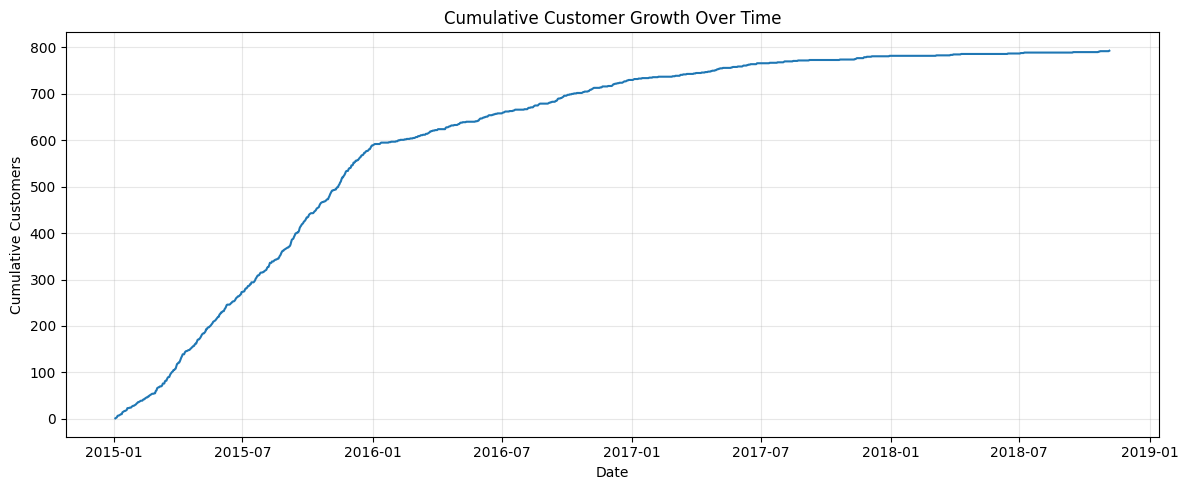

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_customers.index,
    daily_customers["Cumulative Customers"]
)

plt.title("Cumulative Customer Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Customers")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Analyze monthly customer acquisition

monthly_customers = (
    daily_customers["New Customers"]
    .resample("ME")
    .sum()
)

print("Monthly customer acquisition:")
display(monthly_customers.to_frame("New Customers").head(12))

# Average new customers for each calendar month
monthly_seasonality = (
    monthly_customers
    .groupby(monthly_customers.index.month)
    .mean()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_seasonality.index = [
    month_names[i - 1] for i in monthly_seasonality.index
]

print("\nAverage new customers by month:")
display(
    monthly_seasonality
    .sort_values(ascending=False)
    .to_frame("Average New Customers")
)

Monthly customer acquisition:


,New Customers
Date,
2015-01-31,30
2015-02-28,25
2015-03-31,63
2015-04-30,53
2015-05-31,55
2015-06-30,47
2015-07-31,43
2015-08-31,50
2015-09-30,68



Average new customers by month:


,Average New Customers
Mar,22.250000
Sep,21.750000
Dec,21.333333
Nov,20.250000
Apr,18.500000
May,18.500000
Jun,16.750000
Aug,16.750000
Oct,14.000000
Jul,13.750000


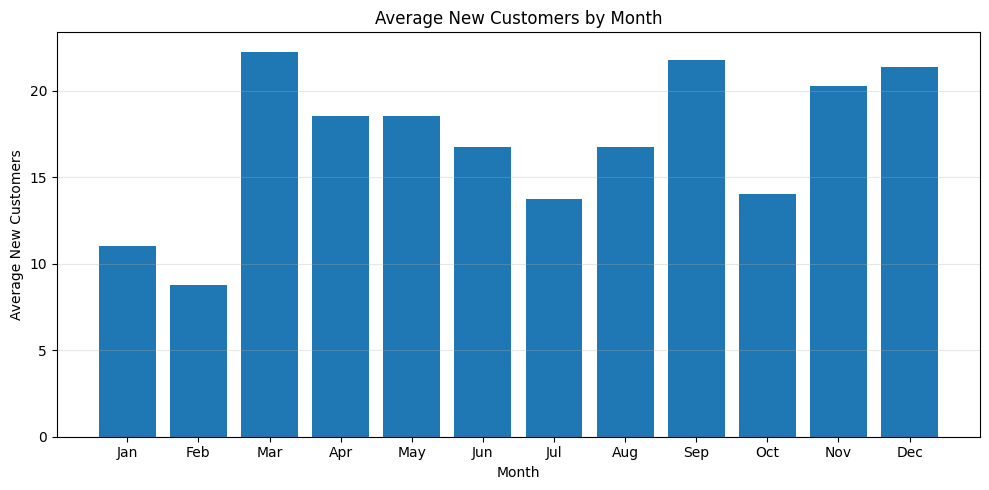

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_seasonality.index,
    monthly_seasonality.values
)

plt.title("Average New Customers by Month")
plt.xlabel("Month")
plt.ylabel("Average New Customers")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Prepare data for baseline forecasting

forecast_data = daily_customers[["New Customers"]].copy()

# Use the final 30 days as test data
train_data = forecast_data.iloc[:-30]
test_data = forecast_data.iloc[-30:]

print("Training period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTesting period:")
print(test_data.index.min(), "to", test_data.index.max())

print("\nTraining records:", len(train_data))
print("Testing records:", len(test_data))


Training period:
2015-01-03 00:00:00 to 2018-10-06 00:00:00

Testing period:
2018-10-07 00:00:00 to 2018-11-05 00:00:00

Training records: 1373
Testing records: 30


In [15]:
# 7-day moving average baseline forecast

# Calculate the average of the last 7 training days
last_7_days = train_data["New Customers"].tail(7)

baseline_prediction = last_7_days.mean()

# Predict the same baseline value for all 30 test days
baseline_forecast = pd.Series(
    baseline_prediction,
    index=test_data.index
)

print("Last 7 days of training data:")
display(last_7_days.to_frame())

print("\nBaseline prediction per day:",
      round(baseline_prediction, 2))

print("\n30-day baseline forecast:")
display(baseline_forecast.head())

Last 7 days of training data:


,New Customers
Date,
2018-09-30,0
2018-10-01,0
2018-10-02,0
2018-10-03,0
2018-10-04,0
2018-10-05,0
2018-10-06,0



Baseline prediction per day: 0.0

30-day baseline forecast:


Date
2018-10-07    0.0
2018-10-08    0.0
2018-10-09    0.0
2018-10-10    0.0
2018-10-11    0.0
Freq: D, dtype: float64

In [16]:
from sklearn.metrics import mean_absolute_error

# Compare baseline predictions with actual test data
baseline_mae = mean_absolute_error(
    test_data["New Customers"],
    baseline_forecast
)

print("Baseline Forecast Performance")
print("-----------------------------")
print("MAE:", round(baseline_mae, 2))

print("\nActual new customers in test period:",
      int(test_data["New Customers"].sum()))

print("Predicted new customers in test period:",
      int(baseline_forecast.sum()))

Baseline Forecast Performance
-----------------------------
MAE: 0.1

Actual new customers in test period: 3
Predicted new customers in test period: 0


In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Build a Holt trend forecasting model
holt_model = ExponentialSmoothing(
    train_data["New Customers"],
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

holt_fitted = holt_model.fit()

# Forecast the 30-day test period
holt_forecast = holt_fitted.forecast(30)

# Customer counts cannot be negative
holt_forecast = holt_forecast.clip(lower=0)

print("Holt 30-day forecast:")
display(holt_forecast.head(10))

print("\nTotal predicted customers:",
      round(holt_forecast.sum(), 2))

ModuleNotFoundError: No module named 'statsmodels'

In [18]:
import statsmodels

print("Statsmodels version:", statsmodels.__version__)

ModuleNotFoundError: No module named 'statsmodels'

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Create a numeric time variable
train_model = train_data.copy()
train_model["Day_Number"] = np.arange(len(train_model))

# Features and target
X_train = train_model[["Day_Number"]]
y_train = train_model["New Customers"]

# Train linear regression model
trend_model = LinearRegression()
trend_model.fit(X_train, y_train)

# Create future 30-day time points
future_days = np.arange(
    len(train_model),
    len(train_model) + 30
).reshape(-1, 1)

# Forecast next 30 days
trend_forecast = trend_model.predict(future_days)

# Customer counts cannot be negative
trend_forecast = np.maximum(trend_forecast, 0)

# Create forecast Series with future dates
future_dates = pd.date_range(
    start=forecast_data.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

trend_forecast = pd.Series(
    trend_forecast,
    index=future_dates,
    name="Predicted New Customers"
)

print("30-Day Trend Forecast:")
display(trend_forecast.to_frame())

print("\nTotal predicted new customers:",
      round(trend_forecast.sum(), 2))

30-Day Trend Forecast:


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Predicted New Customers
2018-11-06,0.0
2018-11-07,0.0
2018-11-08,0.0
2018-11-09,0.0
2018-11-10,0.0
2018-11-11,0.0
2018-11-12,0.0
2018-11-13,0.0
2018-11-14,0.0
2018-11-15,0.0



Total predicted new customers: 0.0


In [20]:
import pandas as pd
import numpy as np

# Load the original business data
sales_df = pd.read_csv("superstore_sales.csv")

# Convert Order Date
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

# Find each customer's first purchase
first_purchase = (
    sales_df.groupby("Customer ID")["Order Date"]
    .min()
    .reset_index()
)

first_purchase.columns = [
    "Customer ID",
    "First Purchase Date"
]

# Count new customers by date
daily_new_customers = (
    first_purchase
    .groupby("First Purchase Date")
    .size()
    .reset_index(name="New Customers")
)

# Create continuous daily dates
date_range = pd.date_range(
    start=daily_new_customers["First Purchase Date"].min(),
    end=daily_new_customers["First Purchase Date"].max(),
    freq="D"
)

daily_customers = (
    daily_new_customers
    .set_index("First Purchase Date")
    .reindex(date_range, fill_value=0)
)

daily_customers.index.name = "Date"

daily_customers["New Customers"] = (
    daily_customers["New Customers"].astype(int)
)

daily_customers["Cumulative Customers"] = (
    daily_customers["New Customers"].cumsum()
)

# Create training and testing sets
forecast_data = daily_customers[["New Customers"]].copy()

train_data = forecast_data.iloc[:-30]
test_data = forecast_data.iloc[-30:]

print("Training records:", len(train_data))
print("Testing records:", len(test_data))
print("Training ends:", train_data.index.max())
print("Testing starts:", test_data.index.min())

Training records: 1373
Testing records: 30
Training ends: 2018-10-06 00:00:00
Testing starts: 2018-10-07 00:00:00


In [21]:
from sklearn.linear_model import LinearRegression

# Create a numeric time variable
train_model = train_data.copy()
train_model["Day_Number"] = np.arange(len(train_model))

# Prepare training data
X_train = train_model[["Day_Number"]]
y_train = train_model["New Customers"]

# Train the trend model
trend_model = LinearRegression()
trend_model.fit(X_train, y_train)

# Create the next 30 days
future_day_numbers = np.arange(
    len(train_model),
    len(train_model) + 30
).reshape(-1, 1)

# Generate forecast
forecast_values = trend_model.predict(future_day_numbers)

# Customer count cannot be negative
forecast_values = np.maximum(forecast_values, 0)

# Create future dates
future_dates = pd.date_range(
    start=test_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

# Store predictions
trend_forecast = pd.Series(
    forecast_values,
    index=future_dates,
    name="Predicted New Customers"
)

print("30-Day Future Customer Forecast:")
display(trend_forecast.to_frame())

print("\nTotal predicted new customers:",
      round(trend_forecast.sum(), 2))

30-Day Future Customer Forecast:


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Predicted New Customers
2018-11-06,0.0
2018-11-07,0.0
2018-11-08,0.0
2018-11-09,0.0
2018-11-10,0.0
2018-11-11,0.0
2018-11-12,0.0
2018-11-13,0.0
2018-11-14,0.0
2018-11-15,0.0



Total predicted new customers: 0.0


In [22]:
from sklearn.linear_model import LinearRegression

# Prepare cumulative customer growth data
growth_data = daily_customers[["Cumulative Customers"]].copy()

# Keep the last 30 days for testing
growth_train = growth_data.iloc[:-30]
growth_test = growth_data.iloc[-30:]

# Create time variable
growth_train = growth_train.copy()
growth_train["Day_Number"] = np.arange(len(growth_train))

# Train linear trend model
growth_model = LinearRegression()

growth_model.fit(
    growth_train[["Day_Number"]],
    growth_train["Cumulative Customers"]
)

# Create future day numbers
future_day_numbers = np.arange(
    len(growth_train),
    len(growth_train) + 30
).reshape(-1, 1)

# Forecast cumulative customers
growth_forecast_values = growth_model.predict(
    future_day_numbers
)

# Customer count cannot decrease
growth_forecast_values = np.maximum(
    growth_forecast_values,
    growth_train["Cumulative Customers"].iloc[-1]
)

# Future dates
future_dates = pd.date_range(
    start=growth_test.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

# Store forecast
growth_forecast = pd.Series(
    growth_forecast_values,
    index=future_dates,
    name="Predicted Cumulative Customers"
)

print("30-Day Customer Growth Forecast:")
display(growth_forecast.to_frame())

print(
    "\nCurrent customers:",
    int(growth_data["Cumulative Customers"].iloc[-1])
)

print(
    "Predicted customers after 30 days:",
    round(growth_forecast.iloc[-1], 0)
)

print(
    "Expected additional customers:",
    round(
        growth_forecast.iloc[-1]
        - growth_data["Cumulative Customers"].iloc[-1],
        0
    )
)

30-Day Customer Growth Forecast:


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Predicted Cumulative Customers
2018-11-06,949.730466
2018-11-07,950.223770
2018-11-08,950.717073
2018-11-09,951.210376
2018-11-10,951.703680
2018-11-11,952.196983
2018-11-12,952.690287
2018-11-13,953.183590
2018-11-14,953.676893
2018-11-15,954.170197



Current customers: 793
Predicted customers after 30 days: 964.0
Expected additional customers: 171.0


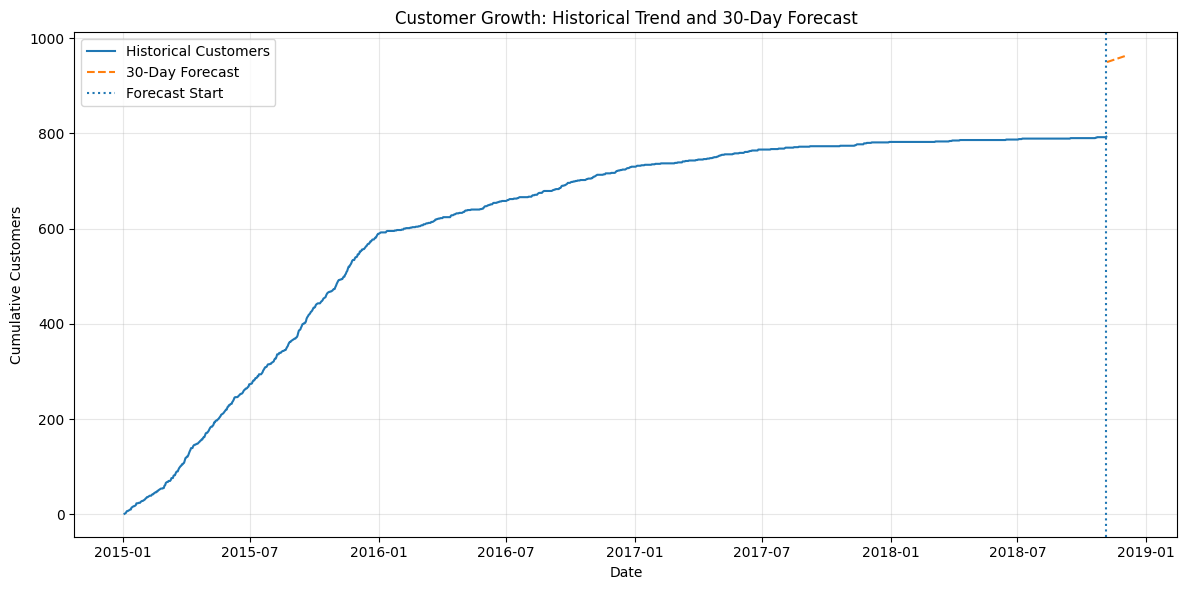

In [23]:
plt.figure(figsize=(12, 6))

# Historical customer growth
plt.plot(
    growth_data.index,
    growth_data["Cumulative Customers"],
    label="Historical Customers"
)

# Forecasted customer growth
plt.plot(
    growth_forecast.index,
    growth_forecast.values,
    linestyle="--",
    label="30-Day Forecast"
)

# Mark the start of forecasting
plt.axvline(
    x=growth_data.index[-1],
    linestyle=":",
    label="Forecast Start"
)

plt.title("Customer Growth: Historical Trend and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Cumulative Customers")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error

# Predict the 30-day test period
test_day_numbers = np.arange(
    len(growth_train),
    len(growth_train) + 30
).reshape(-1, 1)

test_predictions = growth_model.predict(test_day_numbers)

# Calculate MAE
trend_mae = mean_absolute_error(
    growth_test["Cumulative Customers"],
    test_predictions
)

print("Trend Model Evaluation")
print("----------------------")
print("MAE:", round(trend_mae, 2))

print("\nActual customers at end of test period:",
      int(growth_test["Cumulative Customers"].iloc[-1]))

print("Predicted customers at end of test period:",
      round(test_predictions[-1], 2))

Trend Model Evaluation
----------------------
MAE: 165.85

Actual customers at end of test period: 793
Predicted customers at end of test period: 964.04


c:\Users\shrad\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
# Improved baseline using recent customer acquisition

recent_30_days = train_data["New Customers"].tail(30)

recent_daily_average = recent_30_days.mean()

print("Recent 30-day customer acquisition:")
print("Total new customers:", int(recent_30_days.sum()))
print("Average new customers per day:",
      round(recent_daily_average, 3))

# Start from the latest known customer count
current_customers = int(
    growth_train["Cumulative Customers"].iloc[-1]
)

# Predict customer growth for the next 30 days
improved_forecast_values = (
    current_customers
    + recent_daily_average * np.arange(1, 31)
)

improved_forecast = pd.Series(
    improved_forecast_values,
    index=future_dates,
    name="Predicted Cumulative Customers"
)

print("\nImproved 30-Day Forecast:")
display(improved_forecast.to_frame())

print(
    "\nCurrent customers:",
    current_customers
)

print(
    "Predicted customers after 30 days:",
    round(improved_forecast.iloc[-1], 2)
)

print(
    "Expected additional customers:",
    round(
        improved_forecast.iloc[-1] - current_customers,
        2
    )
)

Recent 30-day customer acquisition:
Total new customers: 1
Average new customers per day: 0.033

Improved 30-Day Forecast:


,Predicted Cumulative Customers
2018-11-06,790.033333
2018-11-07,790.066667
2018-11-08,790.100000
2018-11-09,790.133333
2018-11-10,790.166667
2018-11-11,790.200000
2018-11-12,790.233333
2018-11-13,790.266667
2018-11-14,790.300000
2018-11-15,790.333333



Current customers: 790
Predicted customers after 30 days: 791.0
Expected additional customers: 1.0


In [26]:
from sklearn.metrics import mean_absolute_error

# Predict the test period using the recent 30-day average
test_recent_forecast = (
    growth_train["Cumulative Customers"].iloc[-1]
    + recent_daily_average * np.arange(1, 31)
)

# Calculate error
recent_model_mae = mean_absolute_error(
    growth_test["Cumulative Customers"],
    test_recent_forecast
)

print("Recent Average Model Evaluation")
print("--------------------------------")
print("MAE:", round(recent_model_mae, 2))

print("\nActual customers at end of test period:",
      int(growth_test["Cumulative Customers"].iloc[-1]))

print("Predicted customers at end of test period:",
      round(test_recent_forecast[-1], 2))

Recent Average Model Evaluation
--------------------------------
MAE: 0.75

Actual customers at end of test period: 793
Predicted customers at end of test period: 791.0


In [27]:
# Final 30-day customer growth forecast

current_customers = int(
    daily_customers["Cumulative Customers"].iloc[-1]
)

# Use the recent 30-day average acquisition rate
final_forecast_values = (
    current_customers
    + recent_daily_average * np.arange(1, 31)
)

final_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted New Customers": recent_daily_average,
    "Predicted Cumulative Customers": final_forecast_values
})

print("Final 30-Day Customer Growth Forecast")
print("--------------------------------------")

display(final_forecast)

print("\nCurrent customers:", current_customers)

print(
    "Predicted customers after 30 days:",
    round(final_forecast["Predicted Cumulative Customers"].iloc[-1], 2)
)

print(
    "Expected additional customers:",
    round(
        final_forecast["Predicted Cumulative Customers"].iloc[-1]
        - current_customers,
        2
    )
)

Final 30-Day Customer Growth Forecast
--------------------------------------


,Date,Predicted New Customers,Predicted Cumulative Customers
0,2018-11-06,0.033333,793.033333
1,2018-11-07,0.033333,793.066667
2,2018-11-08,0.033333,793.100000
3,2018-11-09,0.033333,793.133333
4,2018-11-10,0.033333,793.166667
5,2018-11-11,0.033333,793.200000
6,2018-11-12,0.033333,793.233333
7,2018-11-13,0.033333,793.266667
8,2018-11-14,0.033333,793.300000
9,2018-11-15,0.033333,793.333333



Current customers: 793
Predicted customers after 30 days: 794.0
Expected additional customers: 1.0


In [28]:
# Save the final 30-day forecast

final_forecast.to_csv(
    "day36_customer_growth_forecast.csv",
    index=False
)

print("Forecast file saved successfully!")
print("File: day36_customer_growth_forecast.csv")

Forecast file saved successfully!
File: day36_customer_growth_forecast.csv


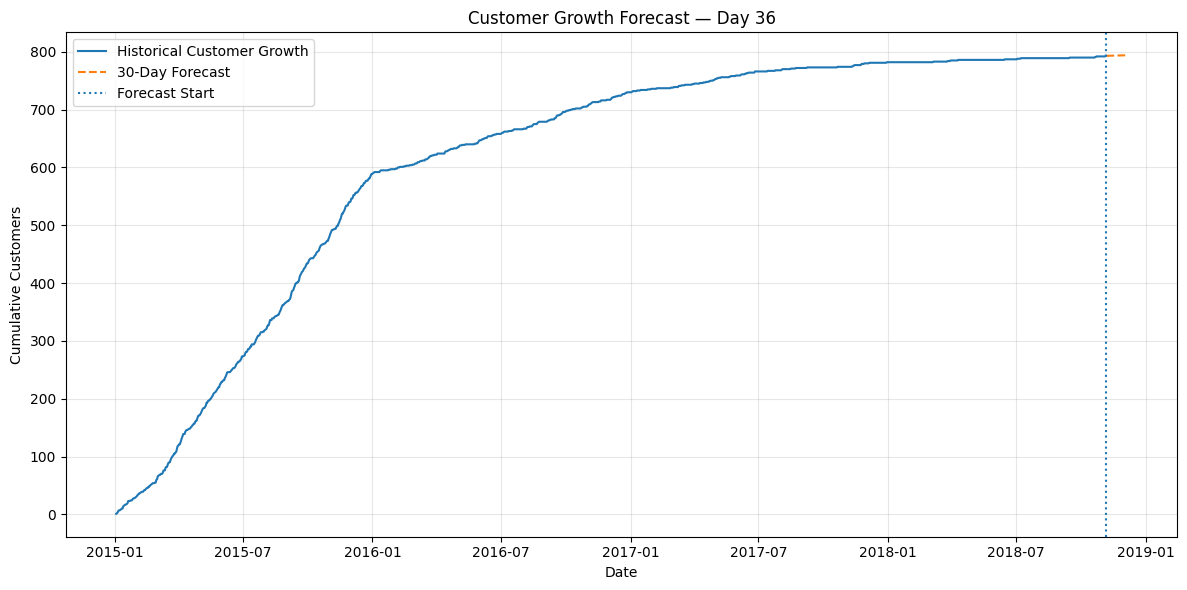

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Historical customer growth
plt.plot(
    daily_customers.index,
    daily_customers["Cumulative Customers"],
    label="Historical Customer Growth"
)

# Final forecast
plt.plot(
    final_forecast["Date"],
    final_forecast["Predicted Cumulative Customers"],
    linestyle="--",
    label="30-Day Forecast"
)

# Forecast starting point
plt.axvline(
    x=daily_customers.index[-1],
    linestyle=":",
    label="Forecast Start"
)

plt.title("Customer Growth Forecast — Day 36")
plt.xlabel("Date")
plt.ylabel("Cumulative Customers")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Forecasting Observations

### Historical Trend
- The customer base increased from the beginning of 2015 to 2018.
- Customer growth was strongest during the earlier part of the historical period.
- Growth slowed considerably toward the end of the dataset.

### Seasonality Analysis
- Monthly customer acquisition showed variation across months.
- March had the highest average new-customer acquisition.
- February had the lowest average.
- The available data shows monthly variation, but it does not provide strong enough evidence to claim a consistent seasonal pattern.

### Forecasting Model Evaluation

Two baseline approaches were evaluated:

| Model | MAE | Observation |
|---|---:|---|
| Linear Trend | 165.85 | Overestimated recent customer growth |
| Recent 30-Day Average | 0.75 | Performed better on the 30-day holdout period |

The recent 30-day average was selected as the baseline forecasting approach.

### Final 30-Day Projection

- Current customer count: 793
- Forecast horizon: 30 days
- Predicted customer count after 30 days: approximately 794
- Expected additional customers: approximately 1

## Forecasting Risks

1. The forecasting model is a simple baseline and does not capture complex business behavior.
2. External factors such as marketing campaigns, promotions, holidays, and market changes are not included.
3. The historical dataset shows a significant slowdown in customer acquisition over time.
4. A longer historical trend can overestimate future growth when recent growth has slowed.
5. The forecast should be treated as a planning estimate rather than a guaranteed outcome.

## Business Interpretation

The recent data suggests that customer acquisition is currently slow. A business could use this forecast as a signal to investigate customer acquisition strategies, marketing performance, and other factors that may influence future growth.